In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.base import clone
from sklearn.metrics import cohen_kappa_score, make_scorer, confusion_matrix
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy import stats
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import warnings
from sklearn.linear_model import ElasticNetCV, LassoCV, Lasso, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import torch
from torch.utils.data import Dataset

warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv("/content/drive/MyDrive/child-mind-data/train.csv")

In [4]:
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train.shape

(3960, 82)

In [6]:
object_columns = train.select_dtypes(include=['object']).columns

object_columns.tolist()

['id',
 'Basic_Demos-Enroll_Season',
 'CGAS-Season',
 'Physical-Season',
 'Fitness_Endurance-Season',
 'FGC-Season',
 'BIA-Season',
 'PAQ_A-Season',
 'PAQ_C-Season',
 'PCIAT-Season',
 'SDS-Season',
 'PreInt_EduHx-Season']

In [7]:
season_columns = ['Basic_Demos-Enroll_Season','CGAS-Season','Physical-Season','Fitness_Endurance-Season','FGC-Season',
 'BIA-Season','PAQ_A-Season','PAQ_C-Season','PCIAT-Season','SDS-Season','PreInt_EduHx-Season']

In [8]:
train = train.drop(season_columns, axis=1)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 71 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Age                         3960 non-null   int64  
 2   Basic_Demos-Sex                         3960 non-null   int64  
 3   CGAS-CGAS_Score                         2421 non-null   float64
 4   Physical-BMI                            3022 non-null   float64
 5   Physical-Height                         3027 non-null   float64
 6   Physical-Weight                         3076 non-null   float64
 7   Physical-Waist_Circumference            898 non-null    float64
 8   Physical-Diastolic_BP                   2954 non-null   float64
 9   Physical-HeartRate                      2967 non-null   float64
 10  Physical-Systolic_BP                    2954 non-null   floa

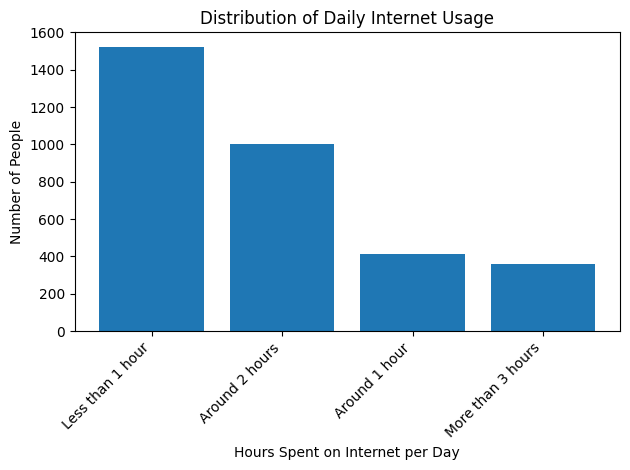

In [10]:
vc = train['PreInt_EduHx-computerinternet_hoursday'].value_counts()  # Count occurrences of each value

# Improved InternetHours_map with clearer categories
InternetHours_map = {
    0: 'Less than 1 hour',
    1: 'Around 1 hour',
    2: 'Around 2 hours',
    3: 'More than 3 hours'
}

# Create labels using the map
labels = [InternetHours_map[label] for label in vc.index]

# Create a bar chart
plt.bar(labels, vc.values)  # Use labels for bar positions

# Customize the bar chart for better visualization
plt.xlabel('Hours Spent on Internet per Day')
plt.ylabel('Number of People')
plt.title('Distribution of Daily Internet Usage')
plt.xticks(rotation=45, ha='right')  # Rotate category labels for readability
plt.tight_layout()  # Adjust spacing to prevent overlapping elements

plt.show()

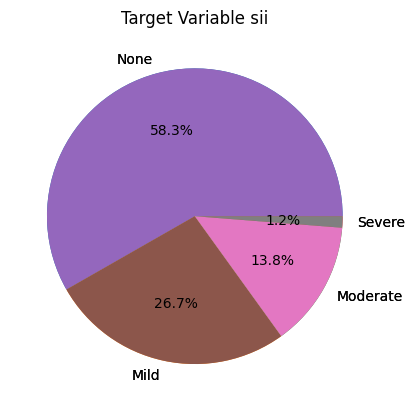

In [11]:
vc = train['sii'].value_counts()

# Map labels to sii
sii_map = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}

# Create labels using the map
labels = [sii_map[label] for label in vc.index]

# Plot the pie chart with the updated labels
plt.pie(vc, labels=labels)
# Plot the pie chart
plt.pie(vc.values, labels=labels, autopct="%1.1f%%")  # Add percentages to pie slices
plt.title('Target Variable sii')
plt.show()

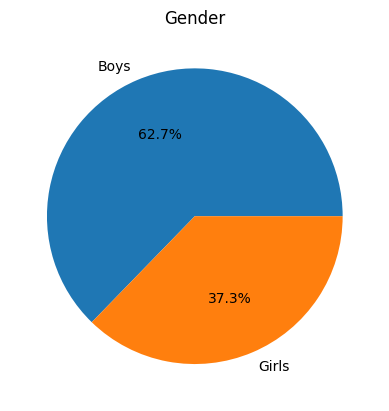

In [12]:
vc = train['Basic_Demos-Sex'].value_counts()

# Extract counts (assuming 'count' column doesn't exist)
counts = vc.values

# Create labels (assuming 'count' column doesn't exist)
labels = ['Boys', 'Girls']  # Assuming 'Male' maps to 'Boys' and 'Female' to 'Girls'

# Plot the pie chart
plt.pie(counts, labels=labels, autopct="%1.1f%%")  # Add percentages to pie slices
plt.title('Gender')
plt.show()

In [13]:
train.head()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,5,0,51.0,16.877316,46.0,50.8,NaN,NaN,NaN,...,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,3.0,2.0
1,000fd460,9,0,NaN,14.035590,48.0,46.0,22.0,75.0,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46.0,64.0,0.0,0.0
2,00105258,10,1,71.0,16.648696,56.5,75.6,NaN,65.0,94.0,...,0.0,2.0,2.0,1.0,1.0,28.0,38.0,54.0,2.0,0.0
3,00115b9f,9,0,71.0,18.292347,56.0,81.6,NaN,60.0,97.0,...,3.0,4.0,3.0,4.0,1.0,44.0,31.0,45.0,0.0,1.0
4,0016bb22,18,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_new = train.copy()#creating a dummy copy of train df for computations

In [15]:
df_new = df_new.drop(columns=['id'])

In [16]:
def feature_engineering(df):

    def assign_group(age):
        thresholds = [5, 6, 7, 8, 10, 12, 14, 17, 22]
        for i, j in enumerate(thresholds):
            if age <= j:
                return i
        return np.nan

    # Age groups
    df["group"] = df['Basic_Demos-Age'].apply(assign_group)

    # BMI (body mass index)
    BMI_map = {0: 16.3,1: 15.9,2: 16.1,3: 16.8,4: 17.3,5: 19.2,6: 20.2,7: 22.3, 8: 23.6}
    df['BMI_mean_norm'] = df[['Physical-BMI', 'BIA-BIA_BMI']].mean(axis=1) / df["group"].map(BMI_map)

    # FGC zone aggregate （aerobic capacity, muscular strength, muscular endurance, flexibility, and body composition.）
    zones = ['FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone',
            'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone',
            'FGC-FGC_TL_Zone']

    df['FGC_Zones_mean'] = df[zones].mean(axis=1)
    df['FGC_Zones_min'] = df[zones].min(axis=1)
    df['FGC_Zones_max'] = df[zones].max(axis=1)

    # Grip（抓力）
    GSD_max_map = {0: 9, 1: 9, 2: 9, 3: 9, 4: 16.2, 5: 19.9, 6: 26.1, 7: 31.3, 8: 35.4}
    GSD_min_map = {0: 9, 1: 9, 2: 9, 3: 9, 4: 14.4, 5: 17.8, 6: 23.4, 7: 27.8, 8: 31.1}

    df['GS_max'] = df[['FGC-FGC_GSND', 'FGC-FGC_GSD']].max(axis=1) / df["group"].map(GSD_max_map)
    df['GS_min'] = df[['FGC-FGC_GSND', 'FGC-FGC_GSD']].min(axis=1) / df["group"].map(GSD_min_map)

    # Curl-ups, push-ups, trunk-lifts... normalized based on age-group
    cu_map = {0: 1.0, 1: 3.0, 2: 5.0, 3: 7.0, 4: 10.0, 5: 14.0, 6: 20.0, 7: 20.0, 8: 20.0}
    pu_map = {0: 1.0, 1: 2.0, 2: 3.0, 3: 4.0, 4: 5.0, 5: 7.0, 6: 8.0, 7: 10.0, 8: 14.0}
    tl_map = {0: 8.0, 1: 8.0, 2: 8.0, 3: 9.0, 4: 9.0, 5: 10.0, 6: 10.0, 7: 10.0, 8: 10.0}

    df["CU_norm"] = df['FGC-FGC_CU'] / df['group'].map(cu_map)
    df["PU_norm"] = df['FGC-FGC_PU'] / df['group'].map(pu_map)
    df["TL_norm"] = df['FGC-FGC_TL'] / df['group'].map(tl_map)

    # Reach
    df["SR_min"] = df[['FGC-FGC_SRL', 'FGC-FGC_SRR']].min(axis=1)
    df["SR_max"] = df[['FGC-FGC_SRL', 'FGC-FGC_SRR']].max(axis=1)

    # BIA Features
    # Energy Expenditure
    bmr_map = {0: 934.0, 1: 941.0, 2: 999.0, 3: 1048.0, 4: 1283.0, 5: 1255.0, 6: 1481.0, 7: 1519.0, 8: 1650.0}
    dee_map = {0: 1471.0, 1: 1508.0, 2: 1640.0, 3: 1735.0, 4: 2132.0, 5: 2121.0, 6: 2528.0, 7: 2566.0, 8: 2793.0}
    df["BMR_norm"] = df["BIA-BIA_BMR"] / df["group"].map(bmr_map)  # 基础代谢率
    df["DEE_norm"] = df["BIA-BIA_DEE"] / df["group"].map(dee_map) # 每日能耗
    df["DEE_BMR"] = df["BIA-BIA_DEE"] - df["BIA-BIA_BMR"]

    # FMM
    ffm_map = {0: 42.0, 1: 43.0, 2: 49.0, 3: 54.0, 4: 60.0, 5: 76.0, 6: 94.0, 7: 104.0, 8: 111.0}
    df["FFM_norm"] = df["BIA-BIA_FFM"] / df["group"].map(ffm_map)

    # ECW ICW
    df["ICW_ECW"] = df["BIA-BIA_ECW"] / df["BIA-BIA_ICW"]

    # Fitness_Endurance
    df["Fitness_Endurance-Time"] = df["Fitness_Endurance-Time_Mins"]*60+df["Fitness_Endurance-Time_Sec"]

    drop_feats = ['FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone',
                'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone',
                'Physical-BMI', 'BIA-BIA_BMI', 'FGC-FGC_CU', 'FGC-FGC_PU', 'FGC-FGC_TL', 'FGC-FGC_SRL', 'FGC-FGC_SRR',
                'BIA-BIA_BMR', 'BIA-BIA_DEE', "BIA-BIA_FFM","Fitness_Endurance-Time_Mins","Fitness_Endurance-Time_Sec"]
    df = df.drop(drop_feats, axis=1)
    return df

In [17]:
train = feature_engineering(train)

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 68 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Age                         3960 non-null   int64  
 2   Basic_Demos-Sex                         3960 non-null   int64  
 3   CGAS-CGAS_Score                         2421 non-null   float64
 4   Physical-Height                         3027 non-null   float64
 5   Physical-Weight                         3076 non-null   float64
 6   Physical-Waist_Circumference            898 non-null    float64
 7   Physical-Diastolic_BP                   2954 non-null   float64
 8   Physical-HeartRate                      2967 non-null   float64
 9   Physical-Systolic_BP                    2954 non-null   float64
 10  Fitness_Endurance-Max_Stage             743 non-null    floa

In [19]:
train.head()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,PU_norm,TL_norm,SR_min,SR_max,BMR_norm,DEE_norm,DEE_BMR,FFM_norm,ICW_ECW,Fitness_Endurance-Time
0,00008ff9,5,0,51.0,46.0,50.8,NaN,NaN,NaN,NaN,...,0.0,0.750000,6.0,7.0,0.998392,1.014276,559.502,0.990148,0.337877,NaN
1,000fd460,9,0,NaN,48.0,46.0,22.0,75.0,70.0,122.0,...,1.0,0.333333,11.0,11.0,0.730051,0.702932,561.994,0.700485,0.286184,NaN
2,00105258,10,1,71.0,56.5,75.6,NaN,65.0,94.0,117.0,...,1.4,0.555556,10.0,10.0,NaN,NaN,NaN,NaN,NaN,453.0
3,00115b9f,9,0,71.0,56.0,81.6,NaN,60.0,97.0,117.0,...,1.0,0.777778,7.0,7.0,0.881863,0.902176,792.010,1.046262,0.512842,577.0
4,0016bb22,18,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
train.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_BMC', 'BIA-BIA_ECW', 'BIA-BIA_FFMI', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM',
       'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total',
       'PAQ_C-PAQ_C_Total', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02',
       'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06',
       'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10',
       'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14',
       'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18',
       'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total',
       'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T',
  

In [21]:
train = train.dropna(subset=['sii'])

In [22]:
train = train.reset_index(drop=True)

In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 68 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   Basic_Demos-Age                         2736 non-null   int64  
 2   Basic_Demos-Sex                         2736 non-null   int64  
 3   CGAS-CGAS_Score                         2342 non-null   float64
 4   Physical-Height                         2530 non-null   float64
 5   Physical-Weight                         2572 non-null   float64
 6   Physical-Waist_Circumference            483 non-null    float64
 7   Physical-Diastolic_BP                   2478 non-null   float64
 8   Physical-HeartRate                      2486 non-null   float64
 9   Physical-Systolic_BP                    2478 non-null   float64
 10  Fitness_Endurance-Max_Stage             731 non-null    floa

In [24]:
exclude = [ 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03',
        'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07',
        'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11',
        'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15',
        'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19',
        'PCIAT-PCIAT_20', 'sii', 'id']

y_model = "PCIAT-PCIAT_Total" # Score, target for the model
y_comp = "sii" # Index, target of the competition
features = [f for f in train.columns if f not in exclude]

Lets do imputation Mean and KNN

In [25]:
import pandas as pd


# Calculate missing value percentage
missing_percent = train.isnull().mean() * 100

# Sort descending for clarity
missing_percent.sort_values(ascending=False).head(15)

,0
PAQ_A-PAQ_A_Total,86.732456
Physical-Waist_Circumference,82.346491
Fitness_Endurance-Time,73.428363
Fitness_Endurance-Max_Stage,73.282164
GS_max,68.128655
GS_min,68.128655
PAQ_C-PAQ_C_Total,47.368421
ICW_ECW,33.735380
BMR_norm,33.735380
DEE_BMR,33.735380


In [26]:
train = train.drop(['PAQ_A-PAQ_A_Total','Physical-Waist_Circumference','Fitness_Endurance-Time','Fitness_Endurance-Max_Stage','GS_max','GS_min'], axis = 1)

In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 62 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   Basic_Demos-Age                         2736 non-null   int64  
 2   Basic_Demos-Sex                         2736 non-null   int64  
 3   CGAS-CGAS_Score                         2342 non-null   float64
 4   Physical-Height                         2530 non-null   float64
 5   Physical-Weight                         2572 non-null   float64
 6   Physical-Diastolic_BP                   2478 non-null   float64
 7   Physical-HeartRate                      2486 non-null   float64
 8   Physical-Systolic_BP                    2478 non-null   float64
 9   BIA-BIA_Activity_Level_num              1813 non-null   float64
 10  BIA-BIA_BMC                             1813 non-null   floa

In [28]:
train = train.drop([ 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03',
        'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07',
        'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11',
        'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15',
        'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19',
        'PCIAT-PCIAT_20'], axis =1)

In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   Basic_Demos-Age                         2736 non-null   int64  
 2   Basic_Demos-Sex                         2736 non-null   int64  
 3   CGAS-CGAS_Score                         2342 non-null   float64
 4   Physical-Height                         2530 non-null   float64
 5   Physical-Weight                         2572 non-null   float64
 6   Physical-Diastolic_BP                   2478 non-null   float64
 7   Physical-HeartRate                      2486 non-null   float64
 8   Physical-Systolic_BP                    2478 non-null   float64
 9   BIA-BIA_Activity_Level_num              1813 non-null   float64
 10  BIA-BIA_BMC                             1813 non-null   floa

In [87]:
train['sii'] = train['sii'].replace(3.0, 2.0)

In [96]:
print(train['sii'].unique())

[2. 0. 1.]


In [98]:
train.head()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,BIA-BIA_Activity_Level_num,...,CU_norm,PU_norm,TL_norm,SR_min,SR_max,BMR_norm,DEE_norm,DEE_BMR,FFM_norm,ICW_ECW
0,00008ff9,5,0,51.0,46.0,50.8,NaN,NaN,NaN,2.0,...,0.0,0.00,0.750000,6.0,7.0,0.998392,1.014276,559.502,0.990148,0.337877
1,000fd460,9,0,NaN,48.0,46.0,75.0,70.0,122.0,2.0,...,0.3,1.00,0.333333,11.0,11.0,0.730051,0.702932,561.994,0.700485,0.286184
2,00105258,10,1,71.0,56.5,75.6,65.0,94.0,117.0,NaN,...,2.0,1.40,0.555556,10.0,10.0,NaN,NaN,NaN,NaN,NaN
3,00115b9f,9,0,71.0,56.0,81.6,60.0,97.0,117.0,3.0,...,1.8,1.00,0.777778,7.0,7.0,0.881863,0.902176,792.010,1.046262,0.512842
4,001f3379,13,1,50.0,59.5,112.2,60.0,73.0,102.0,2.0,...,0.6,0.75,0.800000,10.0,11.0,0.898697,0.789735,665.480,0.893920,0.917917


In [100]:
train.tail()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,BIA-BIA_Activity_Level_num,...,CU_norm,PU_norm,TL_norm,SR_min,SR_max,BMR_norm,DEE_norm,DEE_BMR,FFM_norm,ICW_ECW
2731,ff6c2bb8,8,0,NaN,52.5,67.2,60.0,65.0,112.0,3.0,...,0.000000,0.00,1.333333,8.0,10.0,0.987853,1.014386,724.690,0.972835,0.428064
2732,ff759544,7,1,NaN,48.5,46.6,65.0,75.0,105.0,1.0,...,0.000000,0.00,0.562500,8.5,9.0,0.967254,0.765957,289.883,0.922149,0.497977
2733,ff8a2de4,13,0,60.0,59.5,82.4,71.0,70.0,104.0,3.0,...,0.800000,1.25,1.200000,8.0,9.0,0.814909,0.811590,844.820,0.753316,0.583176
2734,ffcd4dbd,11,0,68.0,60.0,109.8,79.0,99.0,116.0,2.0,...,1.071429,0.00,1.400000,10.0,10.0,0.998996,0.945776,752.250,0.997412,0.602772
2735,ffed1dd5,13,0,70.0,70.7,87.0,59.0,61.0,113.0,4.0,...,NaN,NaN,NaN,NaN,NaN,0.954990,1.174889,1555.780,0.988396,0.641318


In [101]:

from sklearn.impute import KNNImputer


# 2. Separate ID and Target columns
id_col = train['id']
targets = train[['PCIAT-PCIAT_Total', 'sii']]  # keep both targets

# 3. Select features for imputation (drop ID and target columns)
features = train.drop(columns=['id', 'PCIAT-PCIAT_Total', 'sii'])

# 4. Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5, weights='uniform')  # you can tune neighbors
features_imputed = imputer.fit_transform(features)

# 5. Convert imputed array back to DataFrame
features_imputed = pd.DataFrame(features_imputed, columns=features.columns)

# 6. Combine back ID, Targets, and Imputed Features
train_imputed = pd.concat([id_col, targets, features_imputed], axis=1)

# 7. Save the final imputed dataset
train_imputed.to_csv("train_knn_imputed.csv", index=False)

print("✅ KNN Imputation Complete!")
print("New dataset shape:", train_imputed.shape)
print("Remaining missing values:", train_imputed.isnull().sum().sum())


✅ KNN Imputation Complete!
New dataset shape: (2736, 42)
Remaining missing values: 0


In [102]:
train_imputed.head()

,id,PCIAT-PCIAT_Total,sii,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,...,CU_norm,PU_norm,TL_norm,SR_min,SR_max,BMR_norm,DEE_norm,DEE_BMR,FFM_norm,ICW_ECW
0,00008ff9,55.0,2.0,5.0,0.0,51.0,46.0,50.8,61.8,87.6,...,0.0,0.00,0.750000,6.0,7.0,0.998392,1.014276,559.5020,0.990148,0.337877
1,000fd460,0.0,0.0,9.0,0.0,60.4,48.0,46.0,75.0,70.0,...,0.3,1.00,0.333333,11.0,11.0,0.730051,0.702932,561.9940,0.700485,0.286184
2,00105258,28.0,0.0,10.0,1.0,71.0,56.5,75.6,65.0,94.0,...,2.0,1.40,0.555556,10.0,10.0,1.207696,1.249159,1069.4556,1.451359,0.573745
3,00115b9f,44.0,1.0,9.0,0.0,71.0,56.0,81.6,60.0,97.0,...,1.8,1.00,0.777778,7.0,7.0,0.881863,0.902176,792.0100,1.046262,0.512842
4,001f3379,34.0,1.0,13.0,1.0,50.0,59.5,112.2,60.0,73.0,...,0.6,0.75,0.800000,10.0,11.0,0.898697,0.789735,665.4800,0.893920,0.917917


In [103]:
train_imputed.tail()

,id,PCIAT-PCIAT_Total,sii,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,...,CU_norm,PU_norm,TL_norm,SR_min,SR_max,BMR_norm,DEE_norm,DEE_BMR,FFM_norm,ICW_ECW
2731,ff6c2bb8,22.0,0.0,8.0,0.0,71.2,52.5,67.2,60.0,65.0,...,0.000000,0.000,1.333333,8.0,10.0,0.987853,1.014386,724.690,0.972835,0.428064
2732,ff759544,33.0,1.0,7.0,1.0,61.0,48.5,46.6,65.0,75.0,...,0.000000,0.000,0.562500,8.5,9.0,0.967254,0.765957,289.883,0.922149,0.497977
2733,ff8a2de4,32.0,1.0,13.0,0.0,60.0,59.5,82.4,71.0,70.0,...,0.800000,1.250,1.200000,8.0,9.0,0.814909,0.811590,844.820,0.753316,0.583176
2734,ffcd4dbd,31.0,1.0,11.0,0.0,68.0,60.0,109.8,79.0,99.0,...,1.071429,0.000,1.400000,10.0,10.0,0.998996,0.945776,752.250,0.997412,0.602772
2735,ffed1dd5,19.0,0.0,13.0,0.0,70.0,70.7,87.0,59.0,61.0,...,1.200000,2.305,1.153889,8.6,10.0,0.954990,1.174889,1555.780,0.988396,0.641318


In [104]:
train_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   PCIAT-PCIAT_Total                       2736 non-null   float64
 2   sii                                     2736 non-null   float64
 3   Basic_Demos-Age                         2736 non-null   float64
 4   Basic_Demos-Sex                         2736 non-null   float64
 5   CGAS-CGAS_Score                         2736 non-null   float64
 6   Physical-Height                         2736 non-null   float64
 7   Physical-Weight                         2736 non-null   float64
 8   Physical-Diastolic_BP                   2736 non-null   float64
 9   Physical-HeartRate                      2736 non-null   float64
 10  Physical-Systolic_BP                    2736 non-null   floa

Knn Imputer

By going through the above graphs we have considerd that knn imputation performed betted without deviating much from the original stats

In [105]:
df_unw = train_imputed.copy()

In [106]:
unwanted = [ 'id']

In [107]:
df_unw = df_unw.drop(unwanted, axis=1)

In [108]:
original_train = train.copy()

In [109]:
target_col = "sii"
correlations = df_unw.corr()[target_col].drop(target_col).sort_values(ascending=False)
correlation_df = pd.DataFrame({"Feature": correlations.index, "Correlation": correlations.values})


correlation_df.style.background_gradient(cmap="YlOrRd")

,Feature,Correlation
0,PCIAT-PCIAT_Total,0.890293
1,Physical-Height,0.366078
2,Basic_Demos-Age,0.359915
3,group,0.358952
4,PreInt_EduHx-computerinternet_hoursday,0.330754
5,Physical-Weight,0.313542
6,FGC_Zones_max,0.260755
7,ICW_ECW,0.233864
8,SDS-SDS_Total_T,0.220676
9,SDS-SDS_Total_Raw,0.215995


Now we have imputed and checked the feature accuracy

we need id pciat_pciat-total and sii to be merged with the df

In [110]:
train_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   PCIAT-PCIAT_Total                       2736 non-null   float64
 2   sii                                     2736 non-null   float64
 3   Basic_Demos-Age                         2736 non-null   float64
 4   Basic_Demos-Sex                         2736 non-null   float64
 5   CGAS-CGAS_Score                         2736 non-null   float64
 6   Physical-Height                         2736 non-null   float64
 7   Physical-Weight                         2736 non-null   float64
 8   Physical-Diastolic_BP                   2736 non-null   float64
 9   Physical-HeartRate                      2736 non-null   float64
 10  Physical-Systolic_BP                    2736 non-null   floa

In [111]:
train_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   PCIAT-PCIAT_Total                       2736 non-null   float64
 2   sii                                     2736 non-null   float64
 3   Basic_Demos-Age                         2736 non-null   float64
 4   Basic_Demos-Sex                         2736 non-null   float64
 5   CGAS-CGAS_Score                         2736 non-null   float64
 6   Physical-Height                         2736 non-null   float64
 7   Physical-Weight                         2736 non-null   float64
 8   Physical-Diastolic_BP                   2736 non-null   float64
 9   Physical-HeartRate                      2736 non-null   float64
 10  Physical-Systolic_BP                    2736 non-null   floa

In [112]:
df_new_train = train_imputed.copy()

In [44]:
df_new_train = df_new_train.drop(['PCIAT-PCIAT_Total'],axis =1)

In [45]:
df_new_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 41 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   sii                                     2736 non-null   float64
 2   Basic_Demos-Age                         2736 non-null   float64
 3   Basic_Demos-Sex                         2736 non-null   float64
 4   CGAS-CGAS_Score                         2736 non-null   float64
 5   Physical-Height                         2736 non-null   float64
 6   Physical-Weight                         2736 non-null   float64
 7   Physical-Diastolic_BP                   2736 non-null   float64
 8   Physical-HeartRate                      2736 non-null   float64
 9   Physical-Systolic_BP                    2736 non-null   float64
 10  BIA-BIA_Activity_Level_num              2736 non-null   floa

In [46]:
df_train = train_imputed.copy()

In [47]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   PCIAT-PCIAT_Total                       2736 non-null   float64
 2   sii                                     2736 non-null   float64
 3   Basic_Demos-Age                         2736 non-null   float64
 4   Basic_Demos-Sex                         2736 non-null   float64
 5   CGAS-CGAS_Score                         2736 non-null   float64
 6   Physical-Height                         2736 non-null   float64
 7   Physical-Weight                         2736 non-null   float64
 8   Physical-Diastolic_BP                   2736 non-null   float64
 9   Physical-HeartRate                      2736 non-null   float64
 10  Physical-Systolic_BP                    2736 non-null   floa

In [48]:
x_tab = df_train.drop(columns=["sii"]).values
y = df_train['sii'].values

In [49]:
# Create a copy of the DataFrame
df_train = train_imputed.copy()

# Drop both the identifier and the target column to create the feature set
x_tab = df_train.drop(columns=["id", "sii"]).values
y = df_train['sii'].values

# Initialize and apply the scaler
scaler = StandardScaler()
x_tab_scaled = scaler.fit_transform(x_tab)

In [50]:
import pandas as pd

# First, get the feature column names by dropping 'id' and 'sii'
feature_columns = df_train.drop(columns=["id", "sii"]).columns

# Now, create the new DataFrame using the scaled data and the column names
df_scaled = pd.DataFrame(x_tab_scaled, columns=feature_columns)

# You can display the first few rows to verify
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 40 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   PCIAT-PCIAT_Total                       2736 non-null   float64
 1   Basic_Demos-Age                         2736 non-null   float64
 2   Basic_Demos-Sex                         2736 non-null   float64
 3   CGAS-CGAS_Score                         2736 non-null   float64
 4   Physical-Height                         2736 non-null   float64
 5   Physical-Weight                         2736 non-null   float64
 6   Physical-Diastolic_BP                   2736 non-null   float64
 7   Physical-HeartRate                      2736 non-null   float64
 8   Physical-Systolic_BP                    2736 non-null   float64
 9   BIA-BIA_Activity_Level_num              2736 non-null   float64
 10  BIA-BIA_BMC                             2736 non-null   floa

In [51]:
# Select the 'id' and 'sii' columns from the original DataFrame
ids_and_target = df_train[['id', 'sii']]

# Combine the id/target DataFrame with the scaled features DataFrame
# axis=1 tells pandas to join them side-by-side (horizontally)
final_df = pd.concat([ids_and_target, df_scaled], axis=1)

# Display the first few rows and info to verify
print("New combined DataFrame head:")
print(final_df.head())

print("\nNew combined DataFrame info:")
final_df.info()

New combined DataFrame head:
         id  sii  PCIAT-PCIAT_Total  Basic_Demos-Age  Basic_Demos-Sex  \
0  00008ff9  2.0           1.332856        -1.528487        -0.757178   
1  000fd460  0.0          -1.371823        -0.361407        -0.757178   
2  00105258  0.0           0.005105        -0.069637         1.320694   
3  00115b9f  1.0           0.791920        -0.361407        -0.757178   
4  001f3379  1.0           0.300160         0.805674         1.320694   

   CGAS-CGAS_Score  Physical-Height  Physical-Weight  Physical-Diastolic_BP  \
0        -1.289692        -1.356914        -0.865225              -0.608517   
1        -0.443514        -1.083664        -0.977088               0.388539   
2         0.510686         0.077646        -0.287265              -0.366806   
3         0.510686         0.009334        -0.147436              -0.744479   
4        -1.379711         0.487521         0.565692              -0.744479   

   Physical-HeartRate  ...   CU_norm   PU_norm   TL_norm 

In [52]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_tab_scaled, y, test_size=0.2, random_state=42
)

Time series

In [54]:
!pip install pandas pyarrow


In [55]:
df_ts = pd.read_parquet('/content/drive/MyDrive/child-mind-data/series_train.parquet/id=ff18b749/part-0.parquet', engine='pyarrow')

In [56]:
print(df_ts.shape)

(384900, 13)


In [120]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   PCIAT-PCIAT_Total                       2736 non-null   float64
 2   sii                                     2736 non-null   float64
 3   Basic_Demos-Age                         2736 non-null   float64
 4   Basic_Demos-Sex                         2736 non-null   float64
 5   CGAS-CGAS_Score                         2736 non-null   float64
 6   Physical-Height                         2736 non-null   float64
 7   Physical-Weight                         2736 non-null   float64
 8   Physical-Diastolic_BP                   2736 non-null   float64
 9   Physical-HeartRate                      2736 non-null   float64
 10  Physical-Systolic_BP                    2736 non-null   floa

In [113]:
print(final_df['sii'].unique())

[2. 0. 1. 3.]


In [121]:
final_df['sii'] = final_df['sii'].replace(3., 2.)

In [122]:
print(final_df['sii'].unique())

[2. 0. 1.]


In [123]:
df_ts.head()

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,0.738530,-0.593758,0.254381,0.085973,17.239023,0.0,0.000000,4176.000000,38580000000000,3,2,-35.0
1,1,0.511355,-0.619977,0.237698,0.172712,19.684601,0.0,5.333333,4175.583496,38585000000000,3,2,-35.0
2,2,-0.012590,-0.609599,-0.170035,0.058919,-10.710141,0.0,10.666667,4175.166504,38590000000000,3,2,-35.0
3,3,0.748916,-0.077824,0.231160,0.059908,17.126532,0.0,9.714286,4174.750000,38595000000000,3,2,-35.0
4,4,0.178803,-0.148874,-0.618662,0.042323,-56.619637,0.0,8.761905,4174.333496,38600000000000,3,2,-35.0


In [124]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384900 entries, 0 to 384899
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   step                 384900 non-null  uint32 
 1   X                    384900 non-null  float32
 2   Y                    384900 non-null  float32
 3   Z                    384900 non-null  float32
 4   enmo                 384900 non-null  float32
 5   anglez               384900 non-null  float32
 6   non-wear_flag        384900 non-null  float32
 7   light                384900 non-null  float32
 8   battery_voltage      384900 non-null  float32
 9   time_of_day          384900 non-null  int64  
 10  weekday              384900 non-null  int8   
 11  quarter              384900 non-null  int8   
 12  relative_date_PCIAT  384900 non-null  float32
dtypes: float32(9), int64(1), int8(2), uint32(1)
memory usage: 18.4 MB


In [125]:
df_ts.describe()

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
count,384900.000000,384900.000000,384900.000000,384900.000000,384900.000000,384900.000000,384900.0,384900.000000,384900.000000,3.849000e+05,384900.000000,384900.000000,384900.000000
mean,192449.500000,0.035303,-0.015518,-0.042806,0.053595,-3.630944,0.0,94.217140,3842.762451,4.328654e+13,3.975152,2.032362,-23.917351
std,111111.203643,0.639139,0.469632,0.515138,0.142599,36.327793,0.0,312.690369,163.283493,2.481195e+13,1.948179,0.176959,6.441676
min,0.000000,-2.312154,-2.087104,-1.350506,0.000000,-89.744629,0.0,0.000000,3098.166748,0.000000e+00,1.000000,2.000000,-35.000000
25%,96224.750000,-0.580219,-0.321756,-0.414665,0.001506,-26.237488,0.0,1.954338,3741.000000,2.186500e+13,2.000000,2.000000,-29.000000
50%,192449.500000,0.075583,-0.019667,-0.065641,0.014763,-4.154672,0.0,4.000000,3812.000000,4.351000e+13,4.000000,2.000000,-24.000000
75%,288674.250000,0.635173,0.278509,0.311449,0.053592,18.259311,0.0,18.006736,3963.500000,6.453000e+13,6.000000,2.000000,-18.000000
max,384899.000000,1.441266,3.085892,1.728032,3.683850,89.768860,0.0,2644.250000,4176.000000,8.639500e+13,7.000000,3.000000,-13.000000


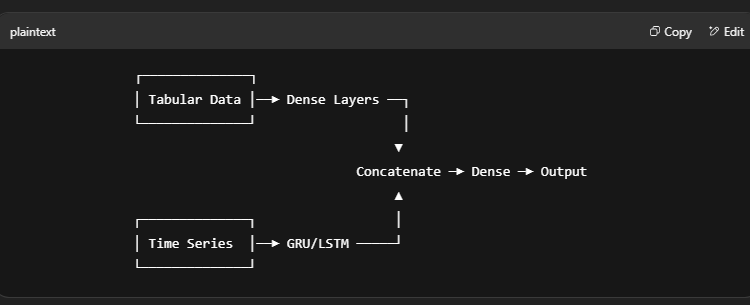

In [126]:
import os

# --- KEY CHANGE IS HERE ---
# Update this path to match the location on your local computer.
# Use a raw string (r'...') to handle backslashes correctly in Windows.
parquet_dir = r'/content/drive/MyDrive/child-mind-data/series_train.parquet'

# The rest of the code remains the same
id_directories = [d for d in os.listdir(parquet_dir) if os.path.isdir(os.path.join(parquet_dir, d))]

all_ids = [d.replace('id=', '') for d in id_directories if d.startswith('id=')]

print(f"Found {len(all_ids)} unique IDs in the directory.")
print(all_ids) # Print the first 5 IDs as a sample

Found 996 unique IDs in the directory.
['fdb6b48b', 'fdc11b96', 'fdea7d9e', 'fdf4691f', 'fe3cbf02', 'ff18b749', 'fe9c71d8', 'ffcd4dbd', 'fecc07d6', 'ffed1dd5', 'fc8e4de4', 'fd0d9bca', 'fd56e059', 'fd028ecc', 'fb3c2c87', 'fb04f7dd', 'fc41be2f', 'fc2c2c08', 'fb9c5a33', 'fc49ba65', 'fa633e39', 'fad07fce', 'fab75c2c', 'fa9a0add', 'f9384fa2', 'fa34f945', 'f9334e08', 'fa3e1e21', 'f8ff0bc8', 'f93010a8', 'f81598bf', 'f8674e15', 'f869d220', 'f8bf4a1c', 'f6c20447', 'f6cc80a9', 'f6c0e2b7', 'f6b719ee', 'f6d6f400', 'f75c957f', 'f74eda33', 'f7fc97cf', 'f7b1374e', 'f6d879aa', 'f64ae747', 'f62b317d', 'f5b2acf0', 'f67908e7', 'f35b607c', 'f4114031', 'f420b05a', 'f44f1227', 'f4d2f5af', 'f57de847', 'f584742f', 'f47a67cc', 'f5ad7abc', 'f47abc42', 'f1baae47', 'f0d76b32', 'f11e17c0', 'f1049268', 'f1bd0f59', 'f09e7b33', 'f3020788', 'f32a9580', 'f285b43c', 'f2d4efd8', 'efa35d35', 'f0957ca1', 'f015a18c', 'ef9617e7', 'ef58dd3c', 'f028534c', 'ee67eb55', 'eef79620', 'eeedcd5e', 'ef07f833', 'ec13a1b9', 'ec6b57b4', 

In [127]:
# 'all_ids' is the list of IDs you got from the Parquet file directories
# Get the list of IDs from your tabular data DataFrame
ids_from_final_df = final_df['id'].tolist()

# Convert both lists of IDs to sets for efficient comparison
set_all_ids = set(all_ids)
set_ids_from_final_df = set(ids_from_final_df)

# Find the intersection of the two sets
common_ids = list(set_all_ids.intersection(set_ids_from_final_df))

print("Common IDs present in both the parquet files and final_df:")
print(common_ids[:10]) # Print first 10 common IDs as a sample
print(f"\nNumber of common IDs: {len(common_ids)}")

Common IDs present in both the parquet files and final_df:
['fb3c2c87', 'c96b9609', 'b7a61f8d', '43629a34', '3ab539f0', '63d4ab9a', '2a6a6b92', 'cd68643b', 'fe9c71d8', '4950e24c']

Number of common IDs: 996


In [128]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm # For a nice progress bar

# --- UPDATE THIS PATH ---
# Path to the directory on your local machine.
# The r'...' syntax handles Windows backslashes correctly.
parquet_dir = r'/content/drive/MyDrive/child-mind-data/series_train.parquet'

In [129]:
# Assumes 'final_df' is already loaded from your previous steps.

# 1. Get all IDs from the Parquet file directory names
id_directories = [d for d in os.listdir(parquet_dir) if os.path.isdir(os.path.join(parquet_dir, d))]
all_ts_ids = [d.replace('id=', '') for d in id_directories if d.startswith('id=')]

# 2. Get all IDs from your main tabular dataframe
all_tabular_ids = final_df['id'].tolist()

# 3. Find the intersection (IDs present in both)
common_ids = list(set(all_ts_ids) & set(all_tabular_ids))

print(f"Found {len(common_ids)} participants with both tabular and time series data.")

Found 996 participants with both tabular and time series data.


In [130]:
# --- FITTING THE GLOBAL SCALER (MEMORY-EFFICIENT METHOD) ---

from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import pandas as pd
import os

# 1. Initialize an empty scaler
scaler_ts = StandardScaler()

# 2. Define the columns you want to process
cols_to_process = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']

# Because this method is memory-efficient, we can use a larger sample (e.g., 200)
# to get a better representation of the data without crashing.
sample_ids = common_ids[:200]

print(f"Fitting scaler incrementally from {len(sample_ids)} files using partial_fit...")
# 3. Loop through each file in the sample
for person_id in tqdm(sample_ids):
    file_path = os.path.join(parquet_dir, f'id={person_id}', 'part-0.parquet')
    try:
        # Load just ONE file at a time
        df_chunk = pd.read_parquet(file_path)

        # Filter for "wear time" from this single file
        wear_data = df_chunk[df_chunk['non-wear_flag'] == 0]

        if not wear_data.empty:
            # Update the scaler's knowledge with this chunk of data.
            # This is the key step: partial_fit() learns incrementally.
            scaler_ts.partial_fit(wear_data[cols_to_process])

    except Exception as e:
        print(f"Could not process file for {person_id}. Error: {e}")

print("Scaler has been successfully fitted using the memory-efficient method.")

Fitting scaler incrementally from 200 files using partial_fit...


  0%|          | 0/200 [00:00<?, ?it/s]

Scaler has been successfully fitted using the memory-efficient method.


In [131]:
df_ts_filtered = df_ts[df_ts['non-wear_flag'] == 0].copy()
print(f"Shape after filtering: {df_ts_filtered.shape}")

Shape after filtering: (384900, 13)


In [132]:
# Identify numerical columns to process (excluding 'step' and 'non-wear_flag')
numerical_cols = df_ts_filtered.select_dtypes(include=np.number).columns.tolist()
cols_to_process = [col for col in numerical_cols if col not in ['step', 'non-wear_flag', 'relative_date_PCIAT']]
print("Columns to be processed:")
print(cols_to_process)

Columns to be processed:
['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage', 'time_of_day', 'weekday', 'quarter']


In [133]:
scaler_ts = StandardScaler()
df_ts_filtered[cols_to_process] = scaler_ts.fit_transform(df_ts_filtered[cols_to_process])
display(df_ts_filtered.head())

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,1.100189,-1.231105,0.576858,0.227106,0.574455,0.0,-0.301258,2.041474,-0.189689,-0.500546,-0.182877,-35.0
1,1,0.744777,-1.286927,0.544476,0.835513,0.641771,0.0,-0.284205,2.038922,-0.189487,-0.500546,-0.182877,-35.0
2,2,-0.074927,-1.264832,-0.246959,0.037347,-0.194858,0.0,-0.267152,2.036368,-0.189285,-0.500546,-0.182877,-35.0
3,3,1.116438,-0.132653,0.531786,0.044283,0.571359,0.0,-0.270197,2.033816,-0.189084,-0.500546,-0.182877,-35.0
4,4,0.224505,-0.283922,-1.117770,-0.079060,-1.458538,0.0,-0.273242,2.031265,-0.188882,-0.500546,-0.182877,-35.0


In [134]:
from sklearn.impute import KNNImputer

knn_imputer_ts = KNNImputer(n_neighbors=3)
df_ts_imputed = pd.DataFrame(knn_imputer_ts.fit_transform(df_ts_filtered[cols_to_process]), columns=cols_to_process)

# Add back the non-processed columns
df_ts_imputed[['step', 'non-wear_flag', 'relative_date_PCIAT']] = df_ts_filtered[['step', 'non-wear_flag', 'relative_date_PCIAT']].reset_index(drop=True)

display(df_ts_imputed.head())

,X,Y,Z,enmo,anglez,light,battery_voltage,time_of_day,weekday,quarter,step,non-wear_flag,relative_date_PCIAT
0,1.100189,-1.231105,0.576858,0.227106,0.574455,-0.301258,2.041474,-0.189689,-0.500546,-0.182877,0,0.0,-35.0
1,0.744777,-1.286927,0.544476,0.835513,0.641771,-0.284205,2.038922,-0.189487,-0.500546,-0.182877,1,0.0,-35.0
2,-0.074927,-1.264832,-0.246959,0.037347,-0.194858,-0.267152,2.036368,-0.189285,-0.500546,-0.182877,2,0.0,-35.0
3,1.116438,-0.132653,0.531786,0.044283,0.571359,-0.270197,2.033816,-0.189084,-0.500546,-0.182877,3,0.0,-35.0
4,0.224505,-0.283922,-1.117770,-0.079060,-1.458538,-0.273242,2.031265,-0.188882,-0.500546,-0.182877,4,0.0,-35.0


In [135]:

# Aggregate daily statistics
daily_stats = df_ts_imputed.groupby('relative_date_PCIAT')[cols_to_process].agg(['count', 'mean', 'std', 'min', lambda x: x.quantile(0.25), lambda x: x.quantile(0.5), lambda x: x.quantile(0.75), 'max'])

# Flatten the multi-level columns
daily_stats.columns = ['_'.join(col).strip() for col in daily_stats.columns.values]

# Reset index to make 'relative_date_PCIAT' a column
daily_stats = daily_stats.reset_index()

display(daily_stats.head())

,relative_date_PCIAT,X_count,X_mean,X_std,X_min,X_<lambda_0>,X_<lambda_1>,X_<lambda_2>,X_max,Y_count,...,weekday_<lambda_2>,weekday_max,quarter_count,quarter_mean,quarter_std,quarter_min,quarter_<lambda_0>,quarter_<lambda_1>,quarter_<lambda_2>,quarter_max
0,-35.0,9564,-0.459257,0.847676,-2.698274,-1.208413,-0.635438,0.014204,1.515390,9564,...,-0.500546,-0.500546,9564,-0.182877,0.0,-0.182877,-0.182877,-0.182877,-0.182877,-0.182877
1,-34.0,17280,-0.605624,0.744345,-2.941786,-1.188988,-0.683780,-0.194739,1.494380,17280,...,0.012754,0.012754,17280,-0.182877,0.0,-0.182877,-0.182877,-0.182877,-0.182877,-0.182877
2,-33.0,17280,-0.781583,0.747815,-3.672567,-1.422396,-0.976303,-0.418355,1.484675,17280,...,0.526055,0.526055,17280,-0.182877,0.0,-0.182877,-0.182877,-0.182877,-0.182877,-0.182877
3,-32.0,17280,-0.706117,0.838047,-3.311016,-1.364744,-0.986169,-0.335915,1.507590,17280,...,1.039355,1.039355,17280,-0.182877,0.0,-0.182877,-0.182877,-0.182877,-0.182877,-0.182877
4,-31.0,17280,-0.541398,0.907107,-2.851849,-1.278865,-0.782854,-0.055391,1.500924,17280,...,1.552656,1.552656,17280,-0.182877,0.0,-0.182877,-0.182877,-0.182877,-0.182877,-0.182877


In [136]:
daily_stats.shape

(23, 81)

In [137]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import os



def process_parquet_file(file_path):

    try:
        df_ts = pd.read_parquet(file_path, engine='pyarrow')


        participant_id = os.path.basename(os.path.dirname(file_path)).replace('id=', '')


        df_ts_filtered = df_ts[df_ts['non-wear_flag'] == 0].copy()

        if df_ts_filtered.empty:
            print(f"No data after filtering for {participant_id}")
            return pd.DataFrame() # Return empty DataFrame if no data

        # Identify numerical columns to process (excluding 'step', 'non-wear_flag', 'relative_date_PCIAT')
        numerical_cols = df_ts_filtered.select_dtypes(include=np.number).columns.tolist()
        cols_to_process = [col for col in numerical_cols if col not in ['step', 'non-wear_flag', 'relative_date_PCIAT']]

        # 3. Scale data (using the pre-fitted scaler)
        df_ts_filtered[cols_to_process] = scaler_ts.transform(df_ts_filtered[cols_to_process])

        # 4. Impute missing values (using the pre-fitted imputer)
        knn_imputer_ts = KNNImputer(n_neighbors=3) # Re-initialize imputer for each file
        df_ts_imputed = pd.DataFrame(knn_imputer_ts.fit_transform(df_ts_filtered[cols_to_process]), columns=cols_to_process)

        # Add back the non-processed columns and the participant id
        df_ts_imputed[['step', 'non-wear_flag', 'relative_date_PCIAT']] = df_ts_filtered[['step', 'non-wear_flag', 'relative_date_PCIAT']].reset_index(drop=True)


        # 5. Aggregate daily statistics
        daily_stats = df_ts_imputed.groupby('relative_date_PCIAT')[cols_to_process].agg(['count', 'mean', 'std', 'min', lambda x: x.quantile(0.25), lambda x: x.quantile(0.5), lambda x: x.quantile(0.75), 'max'])

        # Flatten the multi-level columns
        daily_stats.columns = ['_'.join(col).strip() for col in daily_stats.columns.values]

        # Reset index and add participant id
        daily_stats = daily_stats.reset_index()
        daily_stats['id'] = participant_id

        return daily_stats

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return pd.DataFrame()

In [138]:
import os

# --- UPDATE THIS PATH TO YOUR LOCAL DIRECTORY ---
# The r'...' syntax handles Windows backslashes correctly.
parquet_dir = r'/content/drive/MyDrive/child-mind-data/series_train.parquet'

# This line builds the full list of file paths based on your common_ids
file_paths = [os.path.join(parquet_dir, f'id={id}', 'part-0.parquet') for id in common_ids]

# Verification prints
print(f"Number of files to process: {len(file_paths)}")
print("First 5 file paths:")
print(file_paths[:5])

Number of files to process: 996
First 5 file paths:
['/content/drive/MyDrive/child-mind-data/series_train.parquet/id=fb3c2c87/part-0.parquet', '/content/drive/MyDrive/child-mind-data/series_train.parquet/id=c96b9609/part-0.parquet', '/content/drive/MyDrive/child-mind-data/series_train.parquet/id=b7a61f8d/part-0.parquet', '/content/drive/MyDrive/child-mind-data/series_train.parquet/id=43629a34/part-0.parquet', '/content/drive/MyDrive/child-mind-data/series_train.parquet/id=3ab539f0/part-0.parquet']


In [139]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm # For a nice progress bar

# --- Define the path to your local data directory ---
parquet_dir = r'/content/drive/MyDrive/child-mind-data/series_train.parquet'

In [140]:
# 1. Get all IDs from the Parquet file directory names
all_ts_ids = [d.replace('id=', '') for d in os.listdir(parquet_dir) if os.path.isdir(os.path.join(parquet_dir, d))]

# 2. Get all IDs from your main tabular dataframe
all_tabular_ids = final_df['id'].tolist()

# 3. Find the intersection (IDs present in both)
common_ids = list(set(all_ts_ids) & set(all_tabular_ids))

print(f"Found {len(common_ids)} participants with both tabular and time series data.")

Found 996 participants with both tabular and time series data.


In [141]:
# 1. Initialize an empty scaler
scaler_ts = StandardScaler()

# 2. Define the columns we want to process
cols_to_process = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']

# We'll use a sample of 200 participants to train the scaler
sample_ids = common_ids[:200]

print(f"Fitting scaler incrementally from {len(sample_ids)} files using partial_fit...")
# 3. Loop through each file in the sample and learn from it incrementally
for person_id in tqdm(sample_ids):
    file_path = os.path.join(parquet_dir, f'id={person_id}', 'part-0.parquet')
    try:
        df_chunk = pd.read_parquet(file_path)
        wear_data = df_chunk[df_chunk['non-wear_flag'] == 0]
        if not wear_data.empty:
            scaler_ts.partial_fit(wear_data[cols_to_process]) # Learn from this chunk
    except Exception as e:
        print(f"Could not process file for {person_id}. Error: {e}")

print("Scaler has been successfully fitted.")

Fitting scaler incrementally from 200 files using partial_fit...


  0%|          | 0/200 [00:00<?, ?it/s]

Scaler has been successfully fitted.


In [142]:
def process_parquet_file(file_path, scaler):
    """
    Loads, processes, and aggregates daily stats from a single parquet file.
    """
    try:
        df_ts = pd.read_parquet(file_path, engine='pyarrow')
        participant_id = os.path.basename(os.path.dirname(file_path)).replace('id=', '')

        # 1. Filter out non-wear time
        df_ts_filtered = df_ts[df_ts['non-wear_flag'] == 0].copy()
        if df_ts_filtered.empty:
            return pd.DataFrame()

        # 2. Scale data using the pre-fitted global scaler
        df_ts_filtered[cols_to_process] = scaler.transform(df_ts_filtered[cols_to_process])

        # 3. Aggregate daily statistics
        daily_stats = df_ts_filtered.groupby('relative_date_PCIAT')[cols_to_process].agg(['mean', 'std', 'min', 'max'])
        daily_stats.columns = ['_'.join(col).strip() for col in daily_stats.columns.values]
        daily_stats = daily_stats.reset_index()
        daily_stats['id'] = participant_id

        return daily_stats
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return pd.DataFrame()

In [78]:
# # Create a list of all file paths to be processed
# file_paths = [os.path.join(parquet_dir, f'id={pid}', 'part-0.parquet') for pid in common_ids]

# all_stats_list = []

# print(f"Processing {len(file_paths)} files...")
# for path in tqdm(file_paths):
#     daily_stats = process_parquet_file(path, scaler_ts)
#     if not daily_stats.empty:
#         all_stats_list.append(daily_stats)

# print("Processing complete.")

In [80]:
# # Combine all the individual results into one final DataFrame
# all_daily_stats = pd.concat(all_stats_list, ignore_index=True)

# # Define the output path on your local machine
# output_path = r'/content/drive/MyDrive/child-mind-data/all_daily_stats_processed.parquet'
# all_daily_stats.to_parquet(output_path)

# print(f"Successfully created aggregated data with shape: {all_daily_stats.shape}")
# print(f"Saved to: {output_path}")

# # Display the head of the final DataFrame to verify
# display(all_daily_stats.head())

NameError: name 'all_stats_list' is not defined

In [143]:
import pandas as pd

# --- UPDATE THIS PATH TO YOUR LOCAL FILE ---
# This should be the same path where you saved the file in the previous step.
file_path = r'/content/drive/MyDrive/child-mind-data/all_daily_stats_processed.parquet'

# Load the parquet file from your local disk
all_daily_stats_loaded = pd.read_parquet(file_path, engine='pyarrow')

# Display the first few rows to verify it loaded correctly
display(all_daily_stats_loaded.head())

,relative_date_PCIAT,X_mean,X_std,X_min,X_max,Y_mean,Y_std,Y_min,Y_max,Z_mean,...,anglez_max,light_mean,light_std,light_min,light_max,battery_voltage_mean,battery_voltage_std,battery_voltage_min,battery_voltage_max,id
0,497.0,0.778249,0.607706,-1.531682,1.745420,-0.084020,1.105209,-2.093497,3.425790,0.041573,...,2.351915,0.849529,2.253528,-0.208975,12.694447,1.771656,0.046037,1.691937,1.890548,4926b18a
1,498.0,0.118084,0.076746,-0.108648,1.391272,-0.083560,0.050588,-0.987610,0.121536,-1.508527,...,1.954169,-0.197921,0.013594,-0.206488,-0.173929,1.525413,0.033345,1.506139,1.583021,4926b18a
2,499.0,0.105432,0.002975,0.046698,0.110522,-0.077892,0.009421,-0.092033,0.307533,-1.524597,...,-1.448613,-0.139628,0.005280,-0.145849,-0.128890,1.246942,0.024842,1.205019,1.281901,4926b18a
3,500.0,0.105173,0.000554,0.103603,0.106901,-0.078693,0.000643,-0.082986,-0.076874,-1.521682,...,-1.984548,-0.192953,0.000958,-0.205940,-0.191583,1.120596,0.010656,1.057663,1.128138,4926b18a
4,501.0,-0.169554,0.095064,-0.439818,-0.072802,-0.705164,0.754324,-1.571827,0.042215,-1.224989,...,-0.730554,-0.206488,0.000000,-0.206488,-0.206488,0.822222,0.010720,0.718102,0.827018,4926b18a


In [144]:
all_daily_stats_loaded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25789 entries, 0 to 25788
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   relative_date_PCIAT   25789 non-null  float32
 1   X_mean                25789 non-null  float32
 2   X_std                 25509 non-null  float32
 3   X_min                 25789 non-null  float32
 4   X_max                 25789 non-null  float32
 5   Y_mean                25789 non-null  float32
 6   Y_std                 25509 non-null  float32
 7   Y_min                 25789 non-null  float32
 8   Y_max                 25789 non-null  float32
 9   Z_mean                25789 non-null  float32
 10  Z_std                 25509 non-null  float32
 11  Z_min                 25789 non-null  float32
 12  Z_max                 25789 non-null  float32
 13  enmo_mean             25789 non-null  float32
 14  enmo_std              25509 non-null  float32
 15  enmo_min           

In [145]:
all_daily_stats_loaded.to_csv('daily_stats.csv', index=False)

## Train the hybrid model

**Start from here**

In [147]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import cohen_kappa_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the final tabular and time series data
final_df = pd.read_csv("train_knn_imputed.csv")
all_daily_stats_loaded = pd.read_parquet('/content/drive/MyDrive/child-mind-data/all_daily_stats_processed.parquet', engine='pyarrow')

# --- MASTER SPLIT ---
# Get all unique participant IDs
all_ids = final_df['id'].unique()

# Split IDs into training (60%) and a temporary set (40%)
train_ids, temp_ids = train_test_split(all_ids, test_size=0.4, random_state=42)

# Split the temporary set equally into validation (20%) and test (20%) sets
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

print(f"Total participants: {len(all_ids)}")
print(f"Training participants: {len(train_ids)}")
print(f"Validation participants: {len(val_ids)}")
print(f"Test participants: {len(test_ids)}")

Total participants: 2736
Training participants: 1641
Validation participants: 547
Test participants: 548


In [165]:
final_df_tab = final_df.drop('PCIAT-PCIAT_Total', axis=1)

In [167]:
# 1. Create train, validation, and test sets using the split IDs
train_df_tab = final_df[final_df['id'].isin(train_ids)]
val_df_tab = final_df[final_df['id'].isin(val_ids)]
test_df_tab = final_df[final_df['id'].isin(test_ids)]

# 2. Separate features (X) and target (y) for each set
feature_cols = [col for col in final_df.columns if col not in ['id', 'sii']]

X_train_tab = train_df_tab[feature_cols]
y_train_tab = train_df_tab['sii']

X_val_tab = val_df_tab[feature_cols]
y_val_tab = val_df_tab['sii']

X_test_tab = test_df_tab[feature_cols]
y_test_tab = test_df_tab['sii']

# 3. Scale the features
# IMPORTANT: Fit the scaler ONLY on the training data
scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_val_tab_scaled = scaler_tab.transform(X_val_tab)
X_test_tab_scaled = scaler_tab.transform(X_test_tab)

print(f"Shape of X_train_tab_scaled: {X_train_tab_scaled.shape}")
print(f"Shape of X_val_tab_scaled: {X_val_tab_scaled.shape}")
print(f"Shape of X_test_tab_scaled: {X_test_tab_scaled.shape}")

Shape of X_train_tab_scaled: (597, 40)
Shape of X_val_tab_scaled: (199, 40)
Shape of X_test_tab_scaled: (200, 40)


In [168]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      2736 non-null   object 
 1   PCIAT-PCIAT_Total                       2736 non-null   float64
 2   sii                                     2736 non-null   float64
 3   Basic_Demos-Age                         2736 non-null   float64
 4   Basic_Demos-Sex                         2736 non-null   float64
 5   CGAS-CGAS_Score                         2736 non-null   float64
 6   Physical-Height                         2736 non-null   float64
 7   Physical-Weight                         2736 non-null   float64
 8   Physical-Diastolic_BP                   2736 non-null   float64
 9   Physical-HeartRate                      2736 non-null   float64
 10  Physical-Systolic_BP                    2736 non-null   floa

In [150]:
n_features = X_train_tab_scaled.shape[1]
n_classes = len(final_df['sii'].unique())

model_tabular = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,), kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(), Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model_tabular.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history_tabular = model_tabular.fit(
    X_train_tab_scaled, y_train_tab,
    epochs=50, batch_size=32,
    validation_data=(X_val_tab_scaled, y_val_tab),
    verbose=1 # Set to 1 if you want to see epoch-by-epoch progress
)

print("Tabular model training complete.")

# --- Final Evaluation on the Test Set ---
print("\n--- Evaluating Tabular Model on Test Set ---")
y_pred_tab_probs = model_tabular.predict(X_test_tab_scaled)
y_pred_tab = np.argmax(y_pred_tab_probs, axis=1)

qwk_tab = cohen_kappa_score(y_test_tab, y_pred_tab, weights='quadratic')
acc_tab = accuracy_score(y_test_tab, y_pred_tab)

print(f"Test Accuracy: {acc_tab:.4f}")
print(f"Test QWK Score: {qwk_tab:.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_tab, y_pred_tab))



Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4457 - loss: 1.5386 - val_accuracy: 0.7130 - val_loss: 0.8470
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6513 - loss: 0.9588 - val_accuracy: 0.7587 - val_loss: 0.7212
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7114 - loss: 0.8316 - val_accuracy: 0.8044 - val_loss: 0.6141
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7447 - loss: 0.7168 - val_accuracy: 0.8611 - val_loss: 0.5290
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8112 - loss: 0.6104 - val_accuracy: 0.8775 - val_loss: 0.4824
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8325 - loss: 0.5282 - val_accuracy: 0.8830 - val_loss: 0.4292
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8591 - loss: 0.4861 - val_accuracy: 0.8976 - val_loss: 0.3952
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8437 - loss: 0.4967 - val_accuracy: 0.9196 - val_los

In [151]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import cohen_kappa_score, classification_report, accuracy_score

# --- Load Data ---
# Load the final tabular data (we only need id and sii from it)
final_df = pd.read_csv("train_knn_imputed.csv")
targets_df = final_df[['id', 'sii']]

# Load the processed daily time series statistics
all_daily_stats_loaded = pd.read_parquet('/content/drive/MyDrive/child-mind-data/all_daily_stats_processed.parquet', engine='pyarrow')

# --- Merge to Align Targets ---
# This is the key step you asked about: associating 'sii' with the time series data
ts_data_with_target = pd.merge(all_daily_stats_loaded, targets_df, on='id', how='inner')

print("Successfully merged time series features with target variable 'sii'.")
print(f"Shape of the new merged dataframe: {ts_data_with_target.shape}")
ts_data_with_target.head()

Successfully merged time series features with target variable 'sii'.
Shape of the new merged dataframe: (25789, 31)


,relative_date_PCIAT,X_mean,X_std,X_min,X_max,Y_mean,Y_std,Y_min,Y_max,Z_mean,...,light_mean,light_std,light_min,light_max,battery_voltage_mean,battery_voltage_std,battery_voltage_min,battery_voltage_max,id,sii
0,497.0,0.778249,0.607706,-1.531682,1.745420,-0.084020,1.105209,-2.093497,3.425790,0.041573,...,0.849529,2.253528,-0.208975,12.694447,1.771656,0.046037,1.691937,1.890548,4926b18a,0.0
1,498.0,0.118084,0.076746,-0.108648,1.391272,-0.083560,0.050588,-0.987610,0.121536,-1.508527,...,-0.197921,0.013594,-0.206488,-0.173929,1.525413,0.033345,1.506139,1.583021,4926b18a,0.0
2,499.0,0.105432,0.002975,0.046698,0.110522,-0.077892,0.009421,-0.092033,0.307533,-1.524597,...,-0.139628,0.005280,-0.145849,-0.128890,1.246942,0.024842,1.205019,1.281901,4926b18a,0.0
3,500.0,0.105173,0.000554,0.103603,0.106901,-0.078693,0.000643,-0.082986,-0.076874,-1.521682,...,-0.192953,0.000958,-0.205940,-0.191583,1.120596,0.010656,1.057663,1.128138,4926b18a,0.0
4,501.0,-0.169554,0.095064,-0.439818,-0.072802,-0.705164,0.754324,-1.571827,0.042215,-1.224989,...,-0.206488,0.000000,-0.206488,-0.206488,0.822222,0.010720,0.718102,0.827018,4926b18a,0.0


In [152]:
# Define feature columns (everything except id, date, and target)
ts_feature_cols = [col for col in ts_data_with_target.columns if col not in ['id', 'relative_date_PCIAT', 'sii']]

sequences = []
participant_ids = []
y_sequences = [] # We'll also store the corresponding target for each sequence

# Group by participant and create a sequence for each one
for pid, group in ts_data_with_target.sort_values(by=['id', 'relative_date_PCIAT']).groupby('id'):
    sequences.append(group[ts_feature_cols].values)
    participant_ids.append(pid)
    y_sequences.append(group['sii'].iloc[0]) # sii is the same for all rows of a participant

# Convert lists to numpy arrays
y_sequences = np.array(y_sequences)

# Pad sequences to ensure they all have the same length
max_len = max(len(s) for s in sequences)
X_ts_padded = pad_sequences(sequences, maxlen=max_len, dtype='float32', padding='post')

print(f"\nCreated {len(X_ts_padded)} sequences with a padded length of {max_len}.")


Created 996 sequences with a padded length of 81.


In [153]:
# Split the padded sequences and their corresponding targets
X_train_ts, X_temp_ts, y_train_ts, y_temp_ts = train_test_split(
    X_ts_padded, y_sequences, test_size=0.4, random_state=42, stratify=y_sequences
)

X_val_ts, X_test_ts, y_val_ts, y_test_ts = train_test_split(
    X_temp_ts, y_temp_ts, test_size=0.5, random_state=42, stratify=y_temp_ts
)

# Scale time series features (fit ONLY on training data)
n_samples, n_timesteps, n_features = X_train_ts.shape
scaler_ts = StandardScaler()

# Reshape for scaler -> Scale -> Reshape back to sequences
X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts.reshape(-1, n_features)).reshape(n_samples, n_timesteps, n_features)

n_val_samples, _, _ = X_val_ts.shape
X_val_ts_scaled = scaler_ts.transform(X_val_ts.reshape(-1, n_features)).reshape(n_val_samples, n_timesteps, n_features)

n_test_samples, _, _ = X_test_ts.shape
X_test_ts_scaled = scaler_ts.transform(X_test_ts.reshape(-1, n_features)).reshape(n_test_samples, n_timesteps, n_features)

print(f"Shape of X_train_ts_scaled: {X_train_ts_scaled.shape}")
print(f"Shape of X_val_ts_scaled: {X_val_ts_scaled.shape}")
print(f"Shape of X_test_ts_scaled: {X_test_ts_scaled.shape}")

Shape of X_train_ts_scaled: (597, 81, 28)
Shape of X_val_ts_scaled: (199, 81, 28)
Shape of X_test_ts_scaled: (200, 81, 28)


In [154]:
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import cohen_kappa_score, classification_report, accuracy_score
import numpy as np

n_classes = len(np.unique(y_sequences))

model_ts = Sequential([
    GRU(64, return_sequences=True, input_shape=(max_len, n_features), kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    GRU(32, kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

# FIX: Add gradient clipping and a slightly lower learning rate to the optimizer
optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)

model_ts.compile(optimizer=optimizer,
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# FIX: Add a quick check for NaNs before training
if np.isnan(X_train_ts_scaled).any():
    print("NaNs detected in training data! Imputing with 0.")
    X_train_ts_scaled = np.nan_to_num(X_train_ts_scaled)
if np.isnan(X_val_ts_scaled).any():
    print("NaNs detected in validation data! Imputing with 0.")
    X_val_ts_scaled = np.nan_to_num(X_val_ts_scaled)


print("\n--- Training Time Series Model ---")
history_ts = model_ts.fit(
    X_train_ts_scaled, y_train_ts,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_ts_scaled, y_val_ts),
    verbose=1
)

print("\n--- Final Evaluation on Test Set ---")
y_pred_ts_probs = model_ts.predict(X_test_ts_scaled)
y_pred_ts = np.argmax(y_pred_ts_probs, axis=1)

qwk_ts = cohen_kappa_score(y_test_ts, y_pred_ts, weights='quadratic')
acc_ts = accuracy_score(y_test_ts, y_pred_ts)

print(f"\nTest Accuracy: {acc_ts:.4f}")
print(f"Test QWK Score: {qwk_ts:.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test_ts, y_pred_ts))

NaNs detected in training data! Imputing with 0.
NaNs detected in validation data! Imputing with 0.

--- Training Time Series Model ---
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.5081 - loss: 1.1430 - val_accuracy: 0.5829 - val_loss: 1.0741
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.5833 - loss: 1.0821 - val_accuracy: 0.5829 - val_loss: 1.0615
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.5599 - loss: 1.0793 - val_accuracy: 0.5829 - val_loss: 1.0512
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.5809 - loss: 1.0547 - val_accuracy: 0.5829 - val_loss: 1.0418
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.5799 - loss: 1.0410 - val_accuracy: 0.5829 - val_loss: 1.0354
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.5969 - loss: 1.0367 - val_accuracy: 0.5829 - val_loss: 1.0305
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.5651 - loss: 1.0699 - val_accu

--- Detailed Classification Report (Test Set) ---
              precision    recall  f1-score   support

 SII Class 0       0.58      1.00      0.74       117
 SII Class 1       0.00      0.00      0.00        54
 SII Class 2       0.00      0.00      0.00        29

    accuracy                           0.58       200
   macro avg       0.19      0.33      0.25       200
weighted avg       0.34      0.58      0.43       200

Cohen's Kappa (Unweighted): 0.0000
Mean Absolute Error (MAE): 0.5600

--- Graphical Confusion Matrix (Test Set) ---


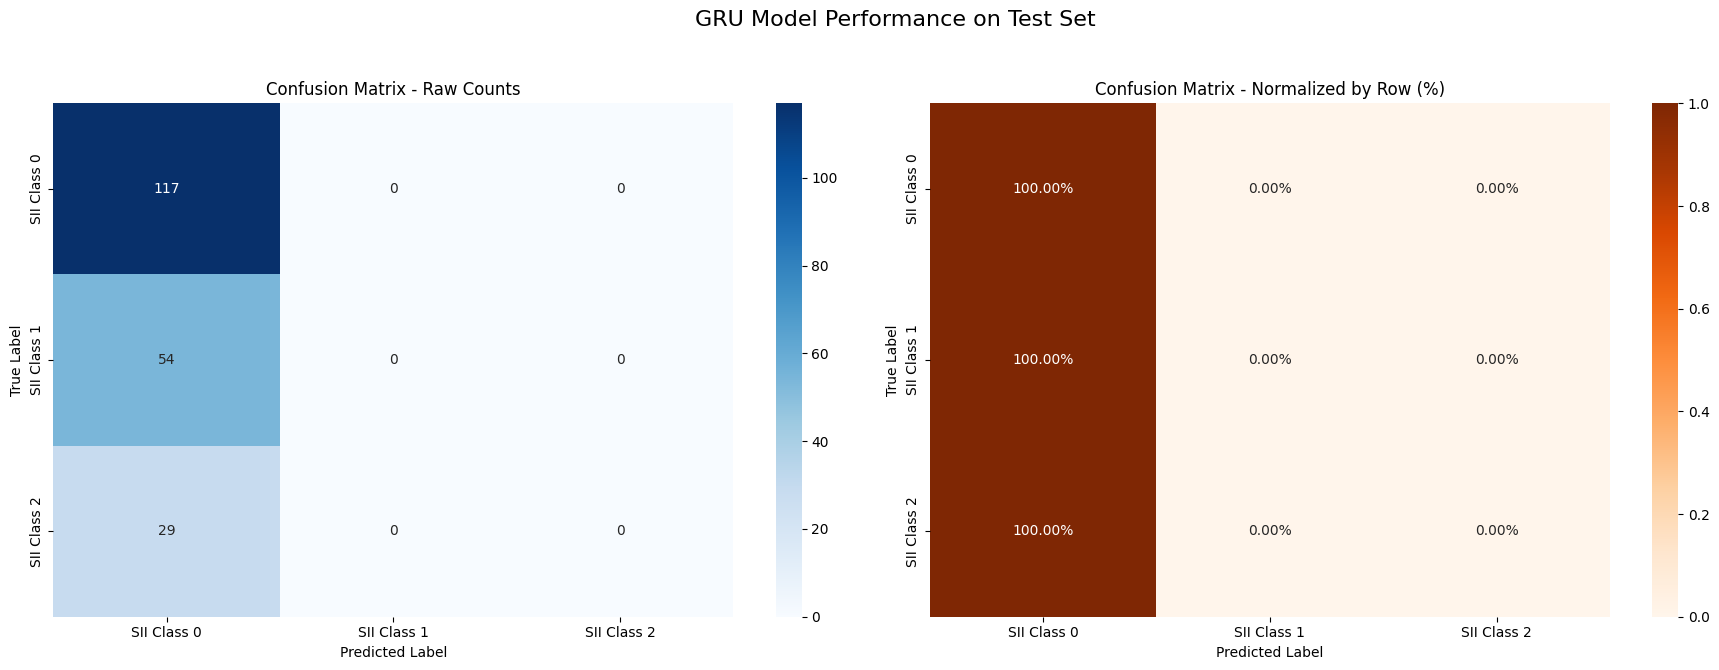


--- Training and Validation History ---


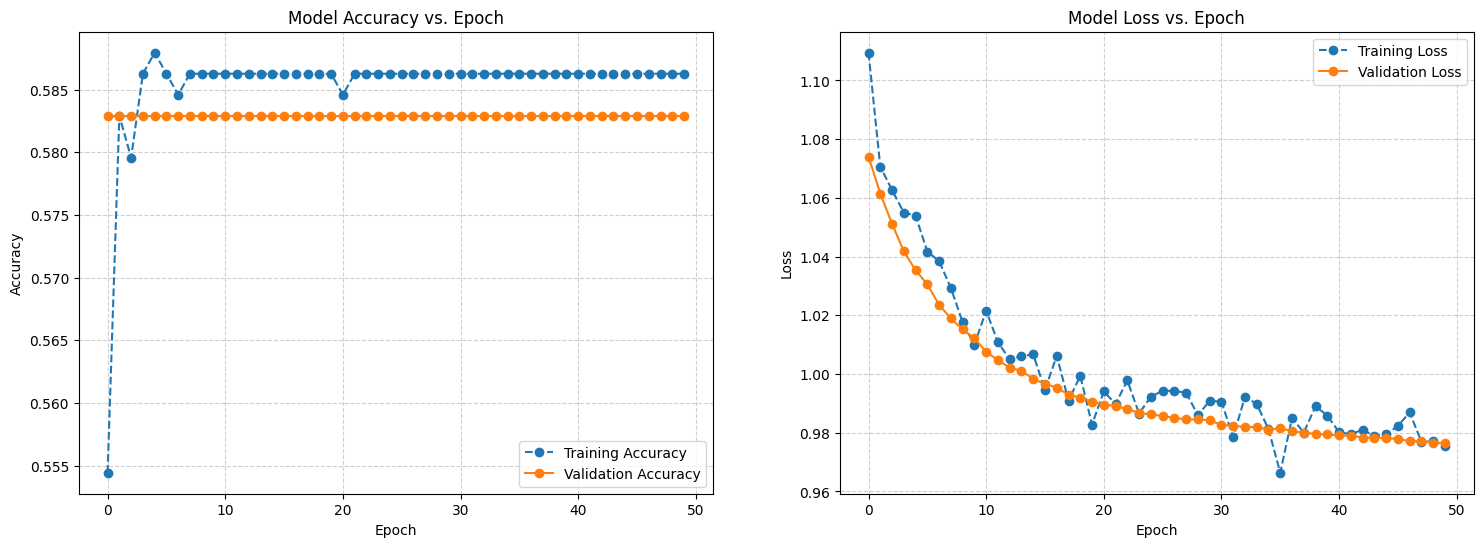

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# --- Ensure these variables are available from the previous step ---
# y_test_ts: The true labels for the test set
# y_pred_ts: The model's predicted labels for the test set
# history_ts: The history object from model.fit()
# ----------------------------------------------------------------

# 1. Generate the Detailed Classification Report
print("--- Detailed Classification Report (Test Set) ---")
class_labels = [f'SII Class {int(i)}' for i in np.unique(y_test_ts)]
print(classification_report(y_test_ts, y_pred_ts, target_names=class_labels))

# 2. Calculate Additional Overall Metrics
kappa = cohen_kappa_score(y_test_ts, y_pred_ts)
mae = np.mean(np.abs(y_test_ts - y_pred_ts))
print(f"Cohen's Kappa (Unweighted): {kappa:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}\n")


# 3. Generate and Plot the Confusion Matrix
print("--- Graphical Confusion Matrix (Test Set) ---")
cm = confusion_matrix(y_test_ts, y_pred_ts)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize for percentages

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('GRU Model Performance on Test Set', fontsize=16)

# Plot raw counts confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_labels, yticklabels=class_labels)
ax1.set_title('Confusion Matrix - Raw Counts')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# Plot normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Oranges', ax=ax2,
            xticklabels=class_labels, yticklabels=class_labels)
ax2.set_title('Confusion Matrix - Normalized by Row (%)')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# 4. Plot Training & Validation Accuracy and Loss
print("\n--- Training and Validation History ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot accuracy
ax1.plot(history_ts.history['accuracy'], label='Training Accuracy', marker='o', linestyle='--')
ax1.plot(history_ts.history['val_accuracy'], label='Validation Accuracy', marker='o', linestyle='-')
ax1.set_title('Model Accuracy vs. Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot loss
ax2.plot(history_ts.history['loss'], label='Training Loss', marker='o', linestyle='--')
ax2.plot(history_ts.history['val_loss'], label='Validation Loss', marker='o', linestyle='-')
ax2.set_title('Model Loss vs. Epoch')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [156]:
# --- Load Data ---
final_df = pd.read_csv("train_knn_imputed.csv")
all_daily_stats_loaded = pd.read_parquet('/content/drive/MyDrive/child-mind-data/all_daily_stats_processed.parquet', engine='pyarrow')

# --- FIX: Identify IDs present in BOTH datasets ---
tabular_ids = set(final_df['id'].unique())
ts_ids = set(all_daily_stats_loaded['id'].unique())

common_ids = list(tabular_ids.intersection(ts_ids))
print(f"Found {len(common_ids)} participants with BOTH tabular and time series data.")

# --- Create the master train/val/test split from these common IDs ---
train_ids, temp_ids = train_test_split(common_ids, test_size=0.4, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

print(f"New split -> Training: {len(train_ids)}, Validation: {len(val_ids)}, Test: {len(test_ids)} participants.")

Found 996 participants with BOTH tabular and time series data.
New split -> Training: 597, Validation: 199, Test: 200 participants.


In [157]:
# --- Prepare Tabular Data ---
feature_cols_tab = [col for col in final_df.columns if col not in ['id', 'sii']]

X_train_tab = final_df[final_df['id'].isin(train_ids)][feature_cols_tab]
y_train = final_df[final_df['id'].isin(train_ids)]['sii']

X_val_tab = final_df[final_df['id'].isin(val_ids)][feature_cols_tab]
y_val = final_df[final_df['id'].isin(val_ids)]['sii']

X_test_tab = final_df[final_df['id'].isin(test_ids)][feature_cols_tab]
y_test = final_df[final_df['id'].isin(test_ids)]['sii']

# Scale tabular features (fitting only on train data)
scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_val_tab_scaled = scaler_tab.transform(X_val_tab)
X_test_tab_scaled = scaler_tab.transform(X_test_tab)


# --- Prepare Time Series Data ---
ts_feature_cols = [col for col in all_daily_stats_loaded.columns if col not in ['id', 'relative_date_PCIAT']]

# Create sequences for ALL common IDs first
sequences, ids = [], []
df_ts_common = all_daily_stats_loaded[all_daily_stats_loaded['id'].isin(common_ids)]
for pid, group in df_ts_common.sort_values(by=['id', 'relative_date_PCIAT']).groupby('id'):
    sequences.append(group[ts_feature_cols].values)
    ids.append(pid)

max_len = max(len(s) for s in sequences)
X_ts_padded = pad_sequences(sequences, maxlen=max_len, dtype='float32', padding='post')
id_to_sequence_map = dict(zip(ids, X_ts_padded))

# Create perfectly aligned train, val, and test sets
X_train_ts = np.array([id_to_sequence_map[id] for id in train_ids])
X_val_ts = np.array([id_to_sequence_map[id] for id in val_ids])
X_test_ts = np.array([id_to_sequence_map[id] for id in test_ids])

# Scale time series features (fitting only on train data)
n_s_tr, n_t_tr, n_f_tr = X_train_ts.shape
scaler_ts = StandardScaler()
X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts.reshape(-1, n_f_tr)).reshape(n_s_tr, n_t_tr, n_f_tr)

n_s_val, n_t_val, n_f_val = X_val_ts.shape
X_val_ts_scaled = scaler_ts.transform(X_val_ts.reshape(-1, n_f_val)).reshape(n_s_val, n_t_val, n_f_val)

n_s_test, n_t_test, n_f_test = X_test_ts.shape
X_test_ts_scaled = scaler_ts.transform(X_test_ts.reshape(-1, n_f_test)).reshape(n_s_test, n_t_test, n_f_test)


print(f"\nData successfully aligned and prepared:")
print(f"X_train_tab_scaled shape: {X_train_tab_scaled.shape}, X_train_ts_scaled shape: {X_train_ts_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_val_tab_scaled shape: {X_val_tab_scaled.shape}, X_val_ts_scaled shape: {X_val_ts_scaled.shape}, y_val shape: {y_val.shape}")


Data successfully aligned and prepared:
X_train_tab_scaled shape: (597, 40), X_train_ts_scaled shape: (597, 81, 28), y_train shape: (597,)
X_val_tab_scaled shape: (199, 40), X_val_ts_scaled shape: (199, 81, 28), y_val shape: (199,)


In [158]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GRU, concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# --- Define Input Shapes ---
# These variables should already be defined from the previous steps
n_tabular_features = X_train_tab_scaled.shape[1]
n_timesteps = X_train_ts_scaled.shape[1]
n_ts_features = X_train_ts_scaled.shape[2]
n_classes = len(np.unique(y_train)) # Use the y_train from the tabular split

# --- Branch 1: Tabular Data Processor ---
tabular_input = Input(shape=(n_tabular_features,), name='tabular_input')
tab_branch = BatchNormalization()(tabular_input) # Normalize data
tab_branch = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(tab_branch)
tab_branch = Dropout(0.4)(tab_branch) # Add dropout for regularization
tab_branch = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(tab_branch)

# --- Branch 2: Time Series Processor ---
ts_input = Input(shape=(n_timesteps, n_ts_features), name='ts_input')
# Stacked GRU layers can capture more complex patterns
ts_branch = GRU(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.001))(ts_input)
ts_branch = Dropout(0.4)(ts_branch)
ts_branch = GRU(32, kernel_regularizer=regularizers.l2(0.001))(ts_branch) # Last GRU does not return sequences

# --- Merge the two branches ---
merged = concatenate([tab_branch, ts_branch])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.4)(merged)
output = Dense(n_classes, activation='softmax', name='output')(merged)

# --- Create and Compile the Hybrid Model ---
hybrid_model = Model(inputs=[tabular_input, ts_input], outputs=output)

# Use the robust optimizer with gradient clipping
optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)

hybrid_model.compile(optimizer=optimizer,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Print a summary of the model architecture
hybrid_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40)        │        160 │ tabular_input[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ts_input            │ (None, 81, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      5,248 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 81, 64)    │     18,048 │ ts_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 81, 64)    │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 32)        │      9,408 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,523 (185.64 KB)

 Trainable params: 47,443 (185.32 KB)

 Non-trainable params: 80 (320.00 B)

In [159]:
from sklearn.utils import class_weight
import numpy as np

# Ensure y_train is your training target data (as a Pandas Series)
# from the previous step.

# Calculate class weights from your specific training data
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.to_numpy() # Use the specific training labels
)

# Convert to a dictionary that Keras can use
class_weight_dict = dict(enumerate(class_weights))

print("Your calculated Class Weights dictionary is:")
print(class_weight_dict)

Your calculated Class Weights dictionary is:
{0: np.float64(0.5605633802816902), 1: np.float64(1.3092105263157894), 2: np.float64(2.2111111111111112)}


--- Checking and Cleaning Data Integrity ---
Data cleaning complete.



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40)        │        160 │ tabular_input[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │      5,248 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ts_input            │ (None, 81, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 64)        │     18,048 │ ts_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,163 (156.89 KB)

 Trainable params: 40,083 (156.57 KB)

 Non-trainable params: 80 (320.00 B)


--- Training Hybrid Model with Improvements ---
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.3633 - loss: 1.3433 - val_accuracy: 0.4523 - val_loss: 1.2411 - learning_rate: 5.0000e-04
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.4285 - loss: 1.2939 - val_accuracy: 0.5477 - val_loss: 1.1748 - learning_rate: 5.0000e-04
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5629 - loss: 1.2084 - val_accuracy: 0.5779 - val_loss: 1.1191 - learning_rate: 5.0000e-04
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5533 - loss: 1.1804 - val_accuracy: 0.5879 - val_loss: 1.0881 - learning_rate: 5.0000e-04
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.6109 - loss: 1.1158 - val_accuracy: 0.6181 - val_loss: 1.0107 - learning_rate: 5.0000e-04
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.6446 - loss: 1.0547 - val_accuracy: 0.6332 - val_loss: 0.9834 - learning_rate: 5.0000e-04
Epoch 7/100
19

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

Test Accuracy: 0.9050
Test QWK Score: 0.9153

Classification Report (Test Set):
               precision    recall  f1-score   support

 SII Class 0       0.98      0.92      0.95       105
 SII Class 1       0.85      0.86      0.85        64
 SII Class 2       0.81      0.94      0.87        31

    accuracy                           0.91       200
   macro avg       0.88      0.91      0.89       200
weighted avg       0.91      0.91      0.91       200



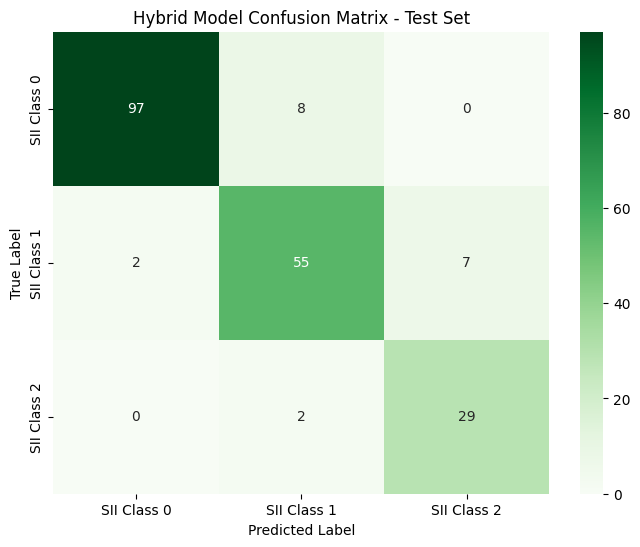

In [160]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score, classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GRU, concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# --- Ensure these scaled data arrays are available from the previous steps ---
# X_train_tab_scaled, y_train
# X_val_tab_scaled,   y_val
# X_test_tab_scaled,  y_test
# X_train_ts_scaled,  X_val_ts_scaled, X_test_ts_scaled
# -------------------------------------------------------------------------

# --- FIX 1: Data Integrity Check and Cleaning ---
# Check for and replace any NaN or infinity values in all datasets
print("--- Checking and Cleaning Data Integrity ---")
for name, data in {
    "X_train_tab_scaled": X_train_tab_scaled, "X_val_tab_scaled": X_val_tab_scaled, "X_test_tab_scaled": X_test_tab_scaled,
    "X_train_ts_scaled": X_train_ts_scaled, "X_val_ts_scaled": X_val_ts_scaled, "X_test_ts_scaled": X_test_ts_scaled
}.items():
    if np.isnan(data).any() or np.isinf(data).any():
        print(f"Warning: Found NaN or Inf in {name}. Cleaning array...")
        # Replace NaN with 0, and infinites with large finite numbers
        np.nan_to_num(data, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

print("Data cleaning complete.\n")


# --- Model Definition (Remains the same) ---
n_tabular_features = X_train_tab_scaled.shape[1]
n_timesteps = X_train_ts_scaled.shape[1]
n_ts_features = X_train_ts_scaled.shape[2]
n_classes = len(np.unique(y_train))

# Tabular Branch
tabular_input = Input(shape=(n_tabular_features,), name='tabular_input')
tab_branch = BatchNormalization()(tabular_input)
tab_branch = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(tab_branch)
tab_branch = Dropout(0.4)(tab_branch)
tab_branch = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(tab_branch)

# Time Series Branch
ts_input = Input(shape=(n_timesteps, n_ts_features), name='ts_input')
ts_branch = GRU(64, return_sequences=False, kernel_regularizer=regularizers.l2(0.001))(ts_input)
ts_branch = Dropout(0.4)(ts_branch)

# Merge Branches
merged = concatenate([tab_branch, ts_branch])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.4)(merged)
output = Dense(n_classes, activation='softmax', name='output')(merged)

hybrid_model = Model(inputs=[tabular_input, ts_input], outputs=output)

# --- FIX 2: Use a Robust Optimizer ---
optimizer = Adam(learning_rate=0.0005, clipnorm=1.0) # Lower learning rate + gradient clipping

hybrid_model.compile(optimizer=optimizer,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

hybrid_model.summary()

from tensorflow.keras.callbacks import EarlyStopping

# Stop training if the validation loss doesn't improve for 5 consecutive epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True # This ensures you keep the model from the best epoch
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce the learning rate by half if validation loss doesn't improve for 3 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6 # Set a minimum learning rate
)

# --- New Training Call with Improvements ---

print("\n--- Training Hybrid Model with Improvements ---")

# Combine the callbacks into a list
callbacks_list = [early_stopping, reduce_lr]

# Train the model using the calculated class weights and callbacks
history_improved = hybrid_model.fit(
    [X_train_tab_scaled, X_train_ts_scaled],
    y_train,
    epochs=100,  # Increase epochs; EarlyStopping will handle the rest
    batch_size=32,
    validation_data=([X_val_tab_scaled, X_val_ts_scaled], y_val),
    class_weight=class_weight_dict, # <-- Add class weights here
    callbacks=callbacks_list,        # <-- Add callbacks here
    verbose=1
)


# --- Final Evaluation on the Test Set ---
print("\n--- Final Evaluation of Hybrid Model on Test Set ---")
y_pred_hybrid_probs = hybrid_model.predict([X_test_tab_scaled, X_test_ts_scaled])
y_pred_hybrid = np.argmax(y_pred_hybrid_probs, axis=1)

# Calculate metrics
qwk_hybrid = cohen_kappa_score(y_test, y_pred_hybrid, weights='quadratic')
acc_hybrid = accuracy_score(y_test, y_pred_hybrid)
class_labels = [f'SII Class {int(i)}' for i in np.unique(y_test)]


print(f"\nTest Accuracy: {acc_hybrid:.4f}")
print(f"Test QWK Score: {qwk_hybrid:.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred_hybrid, target_names=class_labels))

# Visualize the Confusion Matrix
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Hybrid Model Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

--- Detailed Classification Report (Test Set) ---
              precision    recall  f1-score   support

 SII Class 0       0.98      0.92      0.95       105
 SII Class 1       0.85      0.86      0.85        64
 SII Class 2       0.81      0.94      0.87        31

    accuracy                           0.91       200
   macro avg       0.88      0.91      0.89       200
weighted avg       0.91      0.91      0.91       200


--- Graphical Confusion Matrix (Test Set) ---


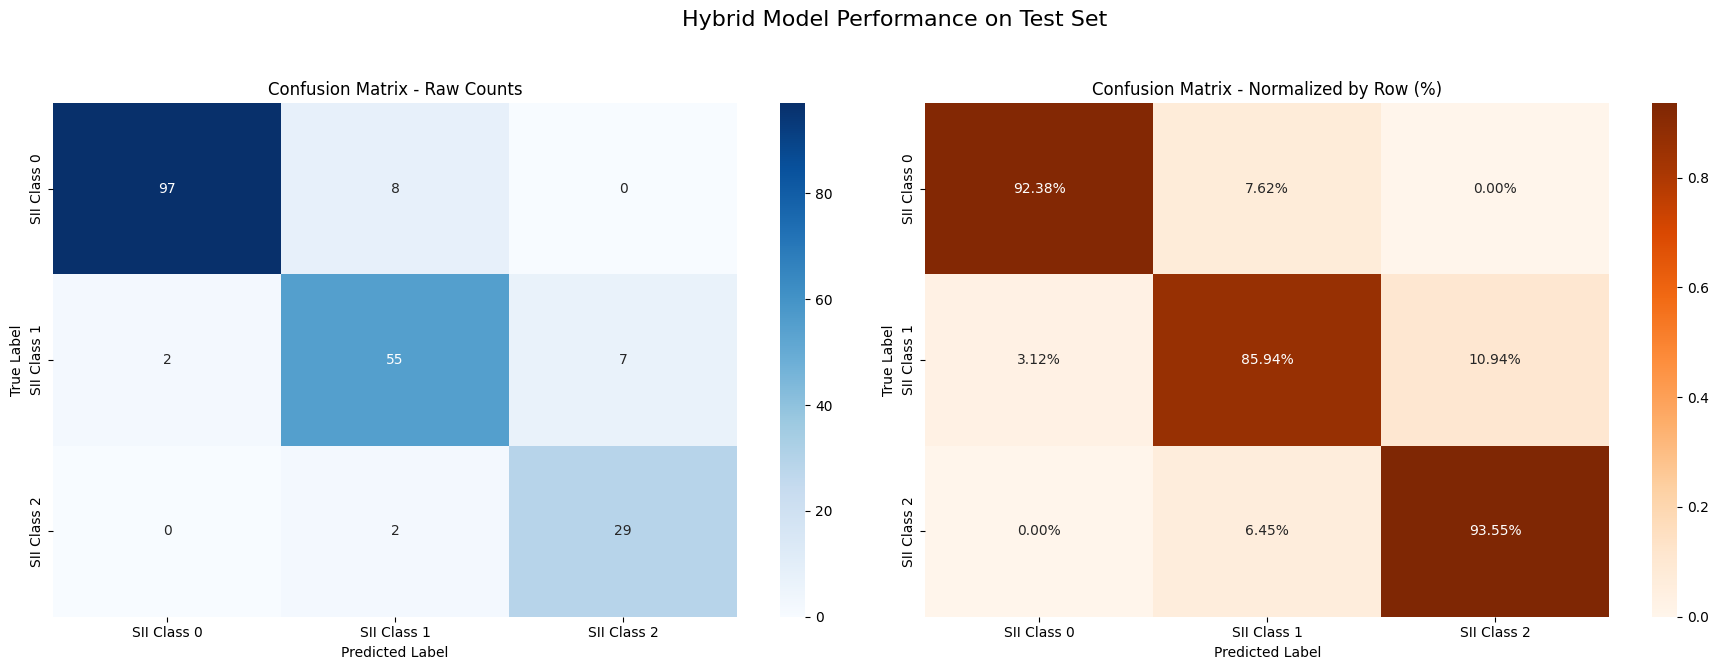


--- Training and Validation History ---


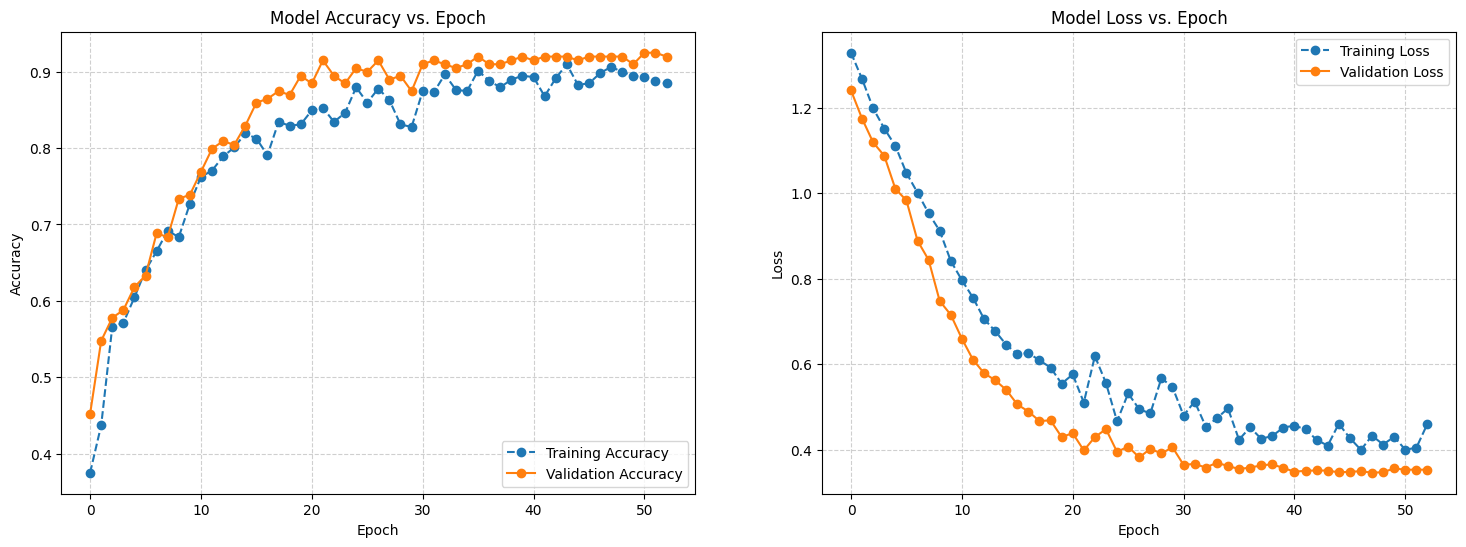


--- Prediction Probabilities for Sample Test Rows ---


KeyError: 0

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# --- Ensure these variables are available from the previous step ---
# y_test: The true labels for the test set.
# y_pred_hybrid: The model's predicted labels for the test set.
# y_pred_hybrid_probs: The raw probability outputs from the model.
# history_improved: The history object from model.fit().
# -----------------------------------------------------------------

# 1. Detailed Classification Report (with F1-Score)
print("--- Detailed Classification Report (Test Set) ---")
class_labels = [f'SII Class {int(i)}' for i in np.unique(y_test)]
print(classification_report(y_test, y_pred_hybrid, target_names=class_labels))


# 2. Graphical Confusion Matrix
print("\n--- Graphical Confusion Matrix (Test Set) ---")
cm = confusion_matrix(y_test, y_pred_hybrid)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize for percentages

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hybrid Model Performance on Test Set', fontsize=16)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_labels, yticklabels=class_labels)
ax1.set_title('Confusion Matrix - Raw Counts')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Oranges', ax=ax2,
            xticklabels=class_labels, yticklabels=class_labels)
ax2.set_title('Confusion Matrix - Normalized by Row (%)')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# 3. Training & Validation History Graphs
print("\n--- Training and Validation History ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(history_improved.history['accuracy'], label='Training Accuracy', marker='o', linestyle='--')
ax1.plot(history_improved.history['val_accuracy'], label='Validation Accuracy', marker='o', linestyle='-')
ax1.set_title('Model Accuracy vs. Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(history_improved.history['loss'], label='Training Loss', marker='o', linestyle='--')
ax2.plot(history_improved.history['val_loss'], label='Validation Loss', marker='o', linestyle='-')
ax2.set_title('Model Loss vs. Epoch')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.show()

# 4. --- NEW: Demonstrate Prediction Probabilities ---
# This section shows the model's confidence for a few specific examples.
print("\n--- Prediction Probabilities for Sample Test Rows ---")

# Select a few samples to display (e.g., the first 5)
num_samples_to_show = 5
sample_indices = range(num_samples_to_show)

# Create a list to hold the data for a DataFrame
prediction_data = []

for i in sample_indices:
    true_label = int(y_test[i])
    predicted_label = y_pred_hybrid[i]
    probabilities = y_pred_hybrid_probs[i]

    # Store data for this sample
    sample_info = {
        'Sample Index': i,
        'True Label': f"Class {true_label}",
        'Predicted Label': f"Class {predicted_label}",
        'Prob Class 0': f"{probabilities[0]:.2%}",
        'Prob Class 1': f"{probabilities[1]:.2%}",
        'Prob Class 2': f"{probabilities[2]:.2%}",
        'Correct?': '✅' if true_label == predicted_label else '❌'
    }
    prediction_data.append(sample_info)

# Create and display a pandas DataFrame for a clean table format
predictions_df = pd.DataFrame(prediction_data)
print(predictions_df.to_string(index=False))

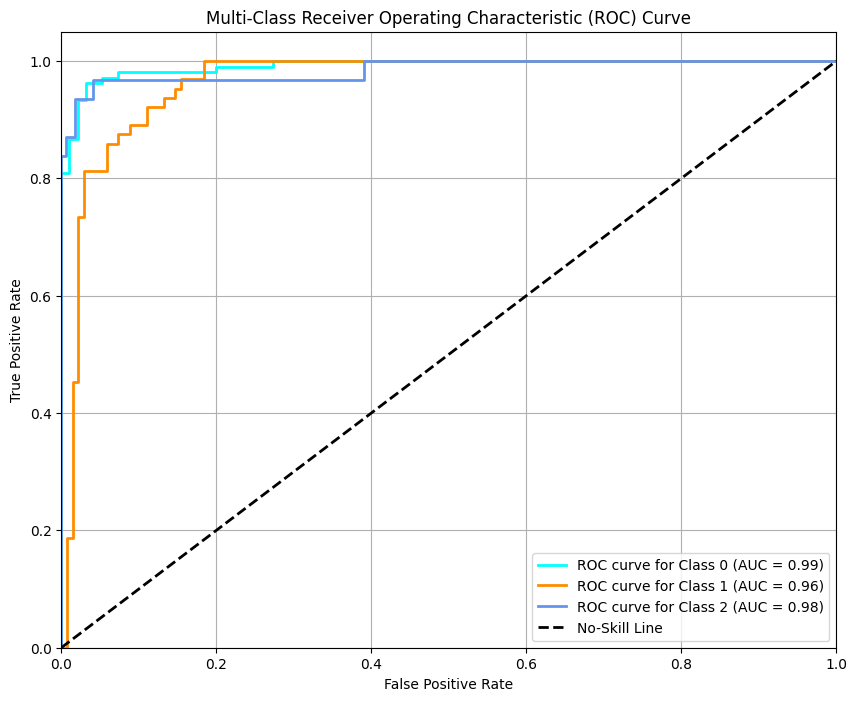

In [163]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt

# --- Ensure these variables are available from your script ---
# y_test: The true integer labels for the test set
# y_pred_hybrid_probs: The output probabilities from your model
# n_classes: The number of unique classes
# -------------------------------------------------------------

# Binarize the true labels to a one-hot encoded format
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

# Dictionaries to store the ROC curve data for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate the ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_hybrid_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green']) # Add more colors if you have more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot the "no-skill" line (random chance)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No-Skill Line')

# Final plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()